In [29]:
%matplotlib widget

import os
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = ".15"

import abtem
import ase
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import numpy as np
import optax
from itertools import chain, cycle, repeat
import tqdm.auto as tqdm
from abtem.multislice import FresnelPropagator
from jax_multislice import get_abtem_transmit, Propagator as convolve2d, shift_kernel, energy2wavelength, get_frequencies

abtem.config.set({"device": "cpu"});


In [30]:
atoms = ase.Atoms('Si', cell=[20, 20, 20], pbc=True)
atoms.center()


In [31]:
base_sampling = 0.1
base_slice_thickness = 0.1

potential = abtem.Potential(
    atoms,
    sampling=base_sampling,
    slice_thickness=base_slice_thickness,
    projection='finite',
)
print(potential.shape)

(200, 200, 200)


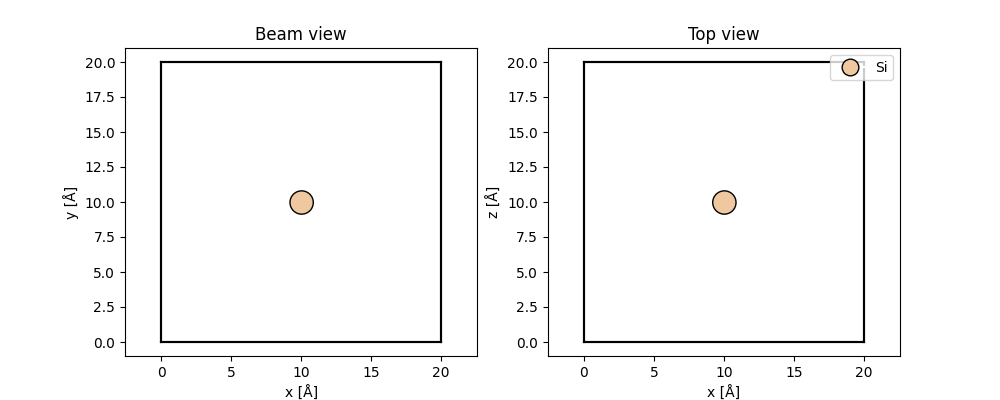

In [32]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
abtem.show_atoms(atoms, ax=ax1, title="Beam view", merge=False)
abtem.show_atoms(atoms, ax=ax2, plane="xz", title="Top view", legend=True);

In [33]:
energy = 200e3
transmit = get_abtem_transmit(potential, energy)

AttributeError: `itemset` was removed from the ndarray class in NumPy 2.0. Use `arr[index] = value` instead.

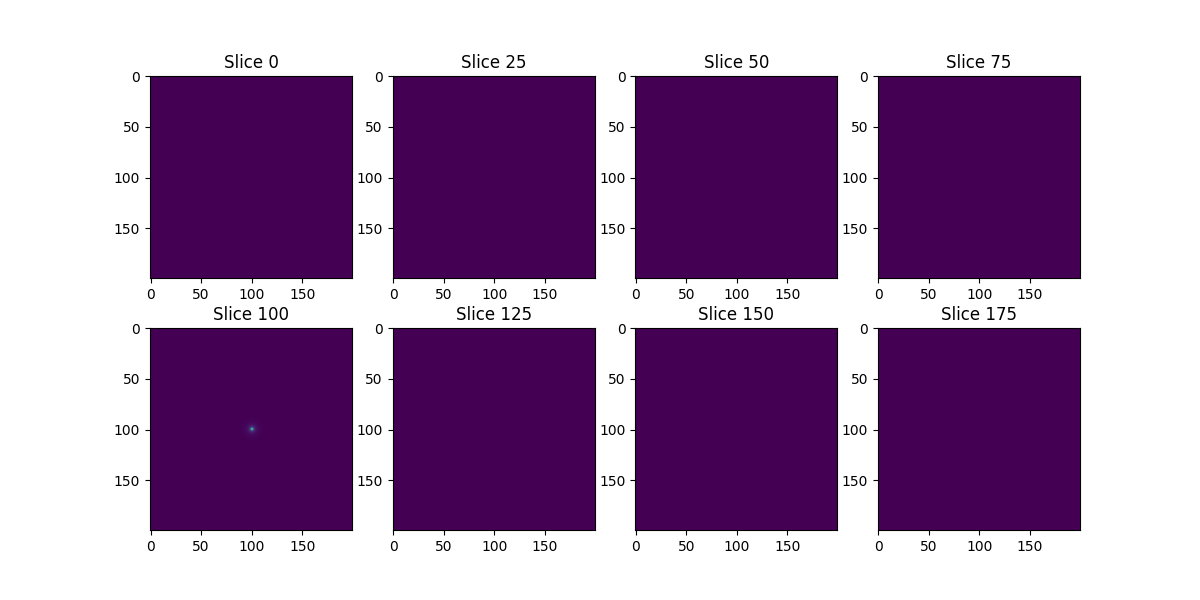

In [ ]:
potential_array = potential.build(lazy=False).array
subset = potential_array[::25]

rows = int(np.floor(np.sqrt(len(subset))))
cols = int(np.ceil(np.sqrt(len(subset))))
if rows * cols < len(subset):
    cols += 1
fig, ax = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
vmin = potential_array.min()
vmax = potential_array.max()
for i, (p, s_ax) in enumerate(zip(subset, ax.ravel())):
    s_ax.imshow(p, vmin=vmin, vmax=vmax)
    s_ax.set_title(f"Slice {i * 25}")

In [ ]:
wavelength = energy2wavelength(energy)
semiangle_cutoff = 40.
defocus = 40.
astigmatism = 0.
astigmatism_angle = 0.

trefoil_angle = np.pi / 7

probe = abtem.Probe(
    energy=energy,
    semiangle_cutoff=semiangle_cutoff,
    defocus=defocus,
)
probe.grid.match(potential)
probe.shape

NameError: name 'energy' is not defined